# Resoluções Práticas e Códigos (Perguntas 6 a 10)

### Pergunta 6: Desconstrução do Código do PCA 

#### O que faz o underscore (_)? 
    O método load_iris retorna duas variáveis: a matriz de atributos (X) e o vetor de classes (y). Ao usar df, _, estamos dizendo ao Python que queremos armazenar a primeira parte no DataFrame df e queremos descartar/ignorar a segunda parte (a classe target), pois técnicas não supervisionadas não utilizam labels.  

#### O que faz o n_components=2? 
    Define a arquitetura de saída do PCA. Ele instrui o algoritmo a compactar as 4 colunas originais do Iris em exatamente 2 novos componentes principais sintéticos.  

#### Qual é a diferença de transform e fit_transform? * fit: 
    O algoritmo estuda os dados e aprende as direções matemáticas (os autovetores) da variação.

        transform: Ele aplica o aprendizado, projetando os dados para a nova escala compactada.  

        fit_transform: Faz os dois passos de uma vez só.  

        Se invertermos: Se você tentar rodar .transform() antes de ter rodado um .fit(), o scikit-learn vai estourar um erro de NotFittedError, porque você está pedindo para ele transformar dados com base em um aprendizado que ele ainda não realizou.

#### Qual é a técnica? 
    uma técnica de Extração de Atributos.

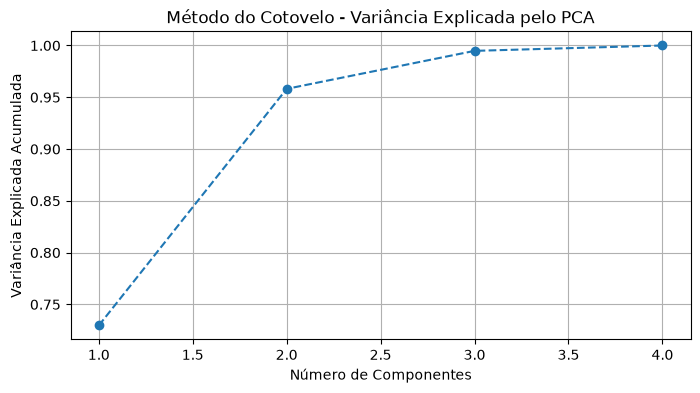

Variância explicada por componente: [0.72962445 0.22850762 0.03668922 0.00517871]
Variância acumulada: [0.72962445 0.95813207 0.99482129 1.        ]


In [1]:
# Pergunta 7: Código do PCA com StandardScaler e Elbow Method

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Carga dos dados (ignorando a classe)
df, _ = load_iris(as_frame=True, return_X_y=True)

# 2. Padronização - ESSENCIAL (Média=0, Variância=1)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 3. Aplicar o PCA para mapear todos os componentes possíveis (4)
pca_completo = PCA()
pca_completo.fit(df_scaled)

# 4. Calcular a variância acumulada
variancia_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

# 5. Plotar o Gráfico do Cotovelo (Elbow)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 5), variancia_acumulada, marker='o', linestyle='--')
plt.title('Método do Cotovelo - Variância Explicada pelo PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

print("Variância explicada por componente:", pca_completo.explained_variance_ratio_)
print("Variância acumulada:", variancia_acumulada)

In [2]:
# Pergunta 8: Depuração do Erro do SelectKBest

from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Carga correta trazendo o DF e o TARGET de forma explícita
df, target = load_iris(as_frame=True, return_X_y=True)

# 2. Correção: k deve ser menor ou igual a 4. Vamos selecionar as 2 melhores (k=2).
# Também adicionamos a função estatística anova (f_classif)
seletor = SelectKBest(score_func=f_classif, k=2)

# 3. Execução passando os atributos E o target para o cálculo estatístico
atributos_filtrados = seletor.fit_transform(df, target)

# Ver quais colunas foram selecionadas
colunas_selecionadas = df.columns[seletor.get_support()]
print("As colunas mais importantes selecionadas foram:", list(colunas_selecionadas))

As colunas mais importantes selecionadas foram: ['petal length (cm)', 'petal width (cm)']


In [3]:
# Pergunta 9: Leitura do Arquivo heart.csv

import pandas as pd

# Ler o arquivo CSV especificando o delimitador se necessário
# Se o arquivo original mantiver o comportamento padrão de CSV, usamos read_csv
df_heart = pd.read_csv('heart.csv')

# Exibir a amostra principal usando o head
display(df_heart.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Pergunta 10: Redução de Dimensionalidade no Dataset Heart

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Carregar a base tratada no passo anterior
df_heart = pd.read_csv('heart.csv')

# 2. Separar as features da label (a coluna 'target' não entra no PCA)
X = df_heart.drop(columns=['target'])
y = df_heart['target']

# 3. Padronizar as escalas (Idade, Batimentos e Pressão possuem ordens de grandeza muito diferentes)
scaler_heart = StandardScaler()
X_scaled = scaler_heart.fit_transform(X)

# 4. Aplicar o PCA para extrair componentes
pca_heart = PCA(n_components=3) # Reduzindo para 3 componentes principais
X_pca = pca_heart.fit_transform(X_scaled)

# 5. Criar o DataFrame final compactado
df_heart_compactado = pd.DataFrame(data=X_pca, columns=['Componente_1', 'Componente_2', 'Componente_3'])
df_heart_compactado['target'] = y.values

print("--- SHAPE ORIGINAL ---", X.shape)
print("--- SHAPE APÓS PCA ---", X_pca.shape)
print("\nVariância explicada pelos 3 componentes:", pca_heart.explained_variance_ratio_.sum())

display(df_heart_compactado.head())

--- SHAPE ORIGINAL --- (1025, 13)
--- SHAPE APÓS PCA --- (1025, 3)

Variância explicada pelos 3 componentes: 0.42580255584834076


,Componente_1,Componente_2,Componente_3,target
0,-0.522556,-1.112803,0.956816,0
1,2.590381,-0.533162,1.467315,0
2,3.042352,-1.327521,-0.424765,0
3,-0.492522,-0.276720,0.801442,0
4,2.187464,1.951477,-0.385539,0
